In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [46]:
# Make the corner plot for the MCMC results
system_name = 'J0607'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [47]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,313.9090,243.9365,-0.625652,0.757317,0.360172,-256.6141
1,314.5158,243.9405,-0.626416,0.756662,0.360145,-256.6926
2,314.4682,243.9408,-0.620511,0.758113,0.361871,-256.6599
3,313.7181,244.0083,-0.621471,0.753123,0.364595,-256.5884
4,313.3912,243.9600,-0.621556,0.757824,0.364835,-256.6170
...,...,...,...,...,...,...
3418,314.0636,243.3718,-0.629727,0.752862,0.380215,-256.4697
3419,312.6558,243.3278,-0.628822,0.755804,0.378828,-256.4216
3420,319.2220,243.3216,-0.627130,0.749272,0.376618,-256.4438
3421,315.3519,243.3252,-0.630391,0.752622,0.376728,-256.5848


In [48]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [49]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

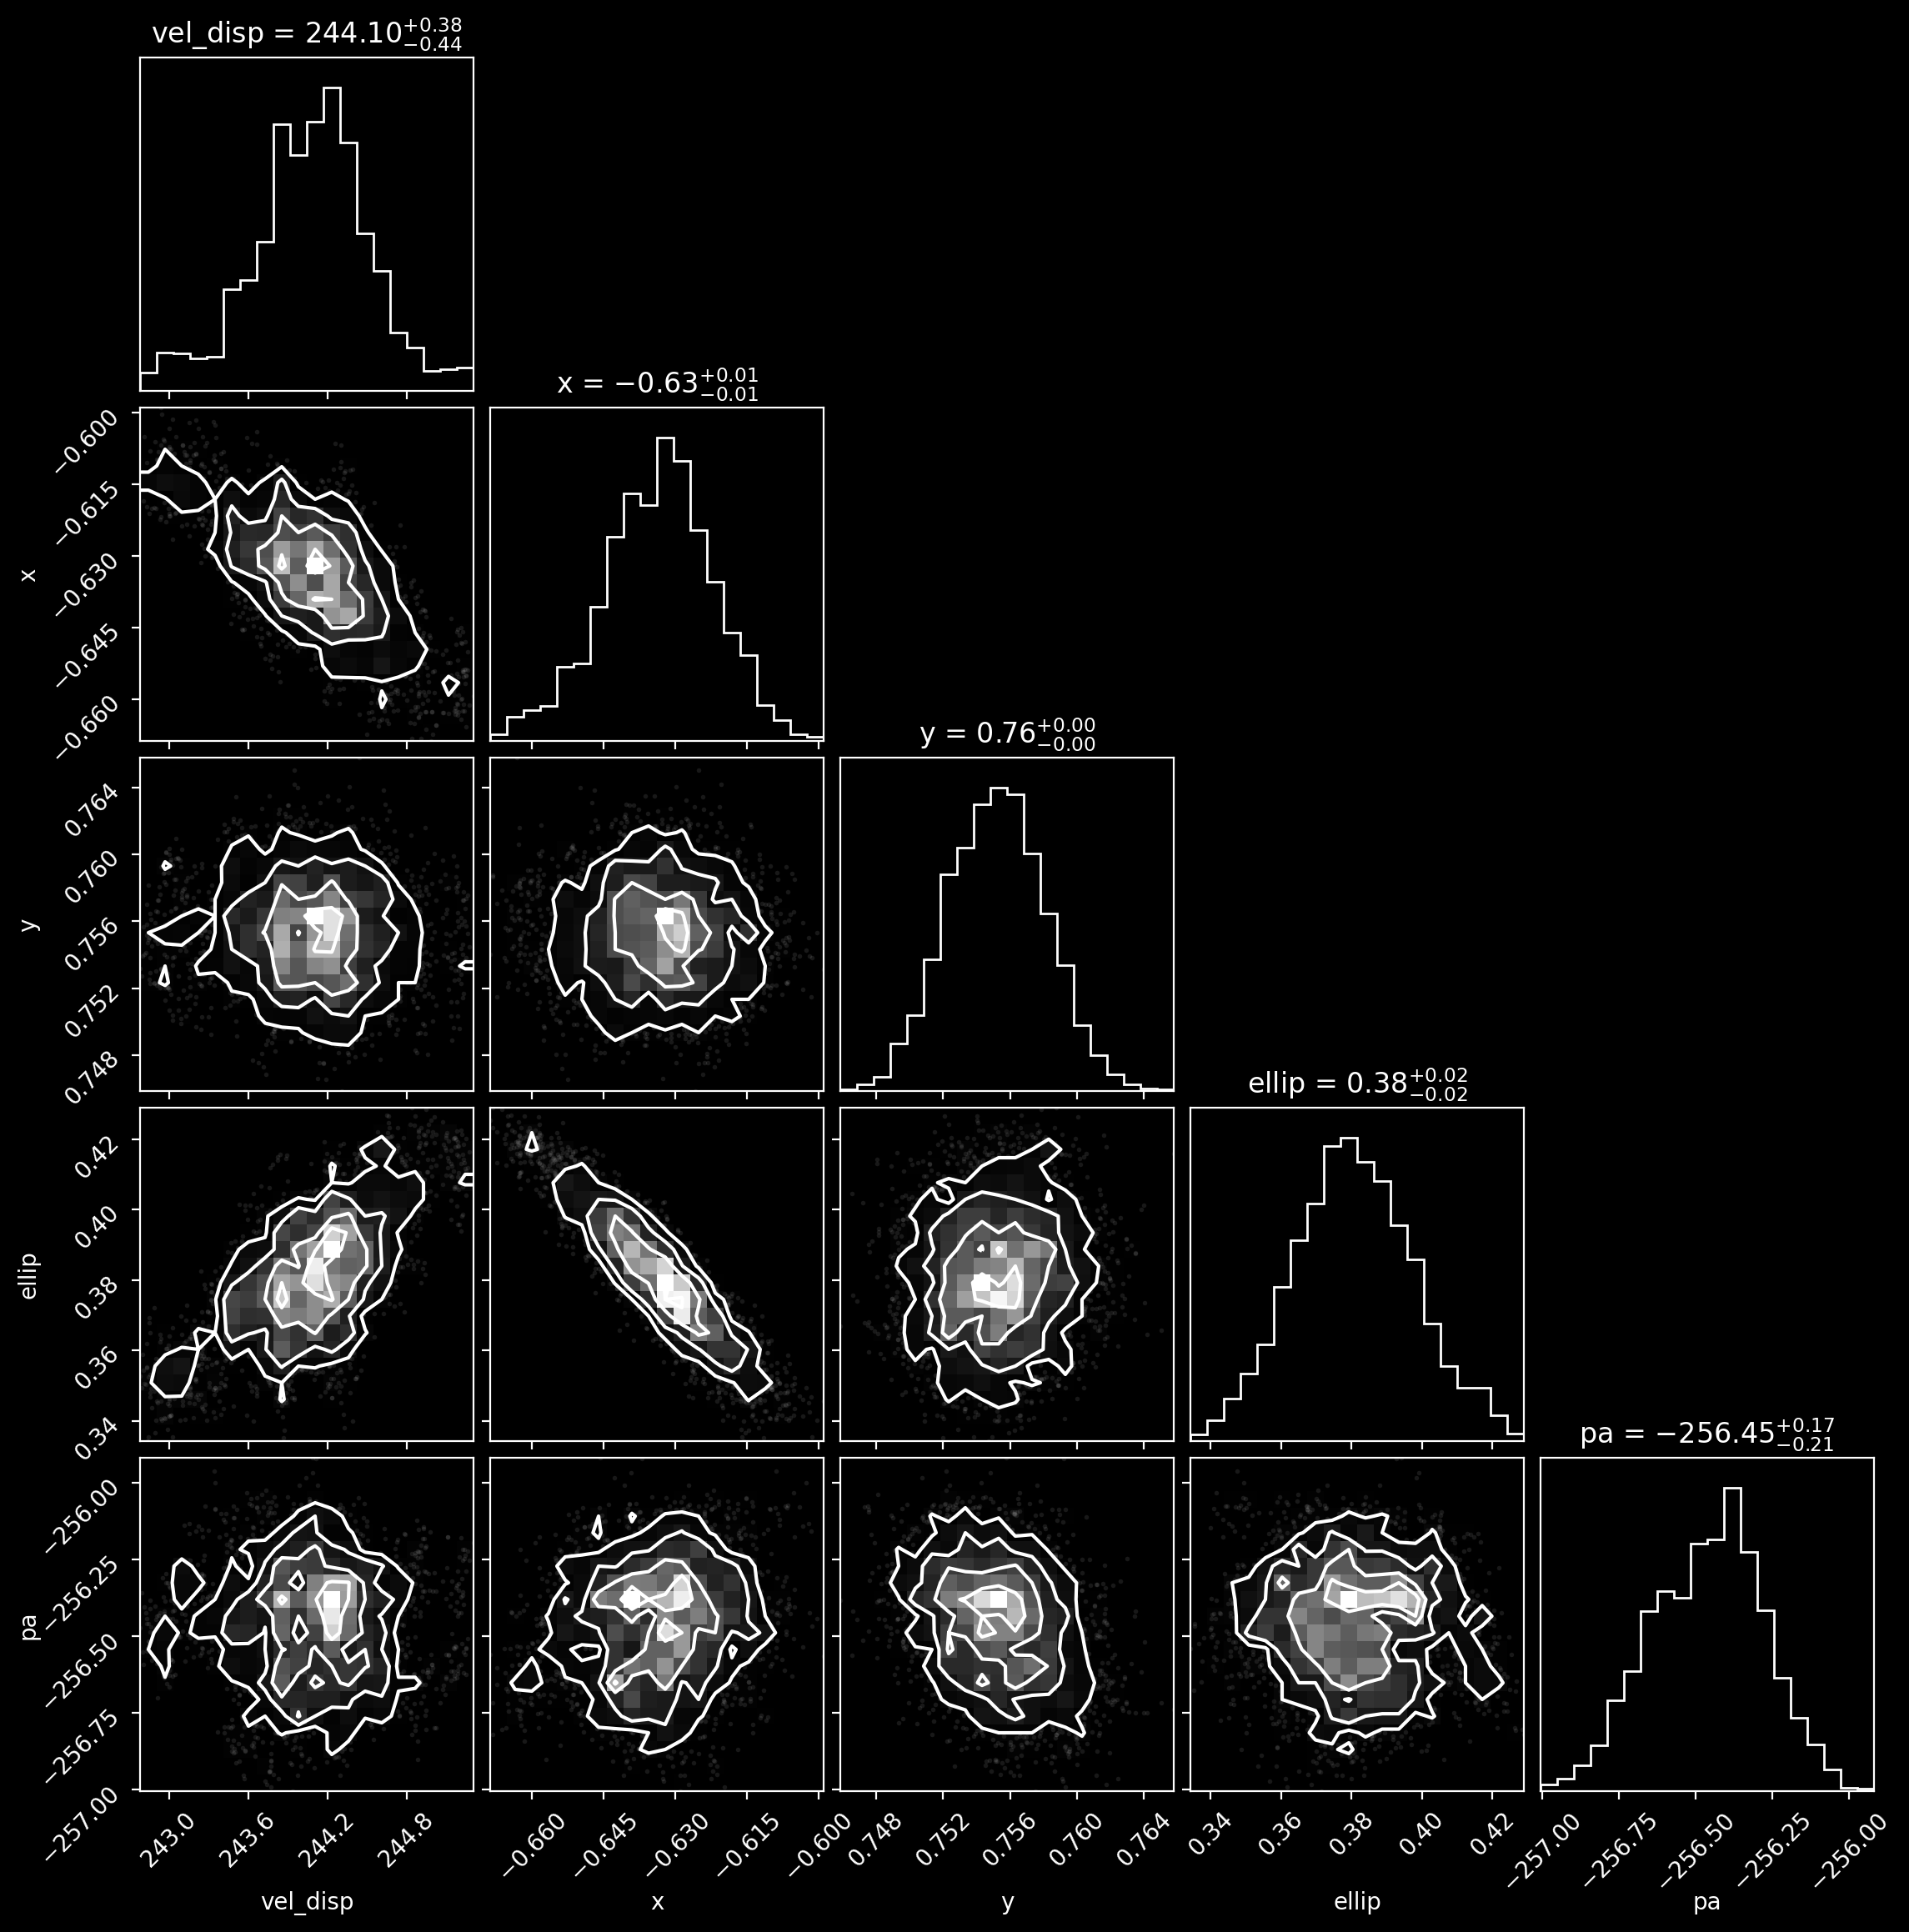

In [50]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')